# Paper task visualization and training (Orhan & Ma Kalman RNN)

Interactive companion to `paper_pytorch`: sample the Kalman Filtering Task and visualize how Target, Gain, Expected rate, and population spikes form the RNN input, then train the RNN and evaluate its checkpoint.

Domain terms: **Trial**, **Batch**, **Batch internals**, **Target**, **Gain**, **Expected rate**, **Population count**, **Instantaneous population estimate**, **Opt mean**, **Opt variance**, **Training loss**, **Fractional RMSE** — see `CONTEXT.md`.

On Google Colab, run the setup cell below once before the imports.

In [11]:
!git clone https://github.com/jgrk28/kalnet.git
%cd kalnet
%pip install -e .

Cloning into 'kalnet'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 22 (delta 5), reused 20 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 546.59 KiB | 4.37 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/home/jacob/kalnet/notebooks/kalnet/kalnet
/home/jacob/kalnet/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
import matplotlib.pyplot as plt
import numpy as np

from paper_pytorch.task import KalmanFilteringTask

plt.rcParams.update(
    {
        "figure.figsize": (8, 3.5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
    }
)

## Sample and visualize the task

Each **Trial** is a length-`stim_dur` sequence. The hidden **Target** `s` and **Gain** determine each neuron's **Expected rate**; Poisson sampling then produces the population spike counts that are the RNN's only input. Optional **Batch internals** let us visualize that generation process and the optimal Kalman filter's estimate.

In [24]:
task = KalmanFilteringTask(
    batch_size=8,
    n_in=50,
    stim_dur=25,
    tr_cond="all_gains",
    seed=0,
)
batch = task.sample(include_internals=True)
assert batch.internals is not None
print(
    f"input {batch.input.shape}, target {batch.target.shape}, "
    f"opt_mean {batch.opt_mean.shape}"
)

trial_idx = 0
t = np.arange(batch.target.shape[1])
phi = task.phi
s = batch.target[trial_idx, :, 0]
m = batch.opt_mean[trial_idx, :, 0]
spikes = batch.input[trial_idx]  # (T, n_in)
gain = batch.internals.gain[trial_idx, :, 0]
expected_rate = batch.internals.expected_rate[trial_idx]
opt_var = batch.internals.opt_var[trial_idx, :, 0]

population_count = spikes.sum(axis=1)
weighted_sum = spikes @ phi
population_estimate = np.full_like(s, np.nan)
np.divide(
    weighted_sum,
    population_count,
    out=population_estimate,
    where=population_count > 0,
)

# Single-timestep likelihood width for Gaussian tuning + Poisson noise:
# var = sigtc_sq / (total spike count). Shrinks as more spikes arrive.
population_sd = np.full_like(s, np.nan)
np.divide(
    task.sigtc_sq,
    population_count,
    out=population_sd,
    where=population_count > 0,
)
population_sd = np.sqrt(population_sd)

selected_times = [
    int(np.argmin(gain)),
    int(np.argmin(np.abs(gain - np.median(gain)))),
    int(np.argmax(gain)),
]
selected_labels = ["lowest", "median", "highest"]

input (8, 25, 50), target (8, 25, 1), opt_mean (8, 25, 1)


### A. How Target and Gain create the RNN input

At each selected timestep, Target `s_t` centers a Gaussian profile over neurons' preferred stimuli and Gain `g_t` scales it. The profile is the Expected rate; the bars are one Poisson sample from it.

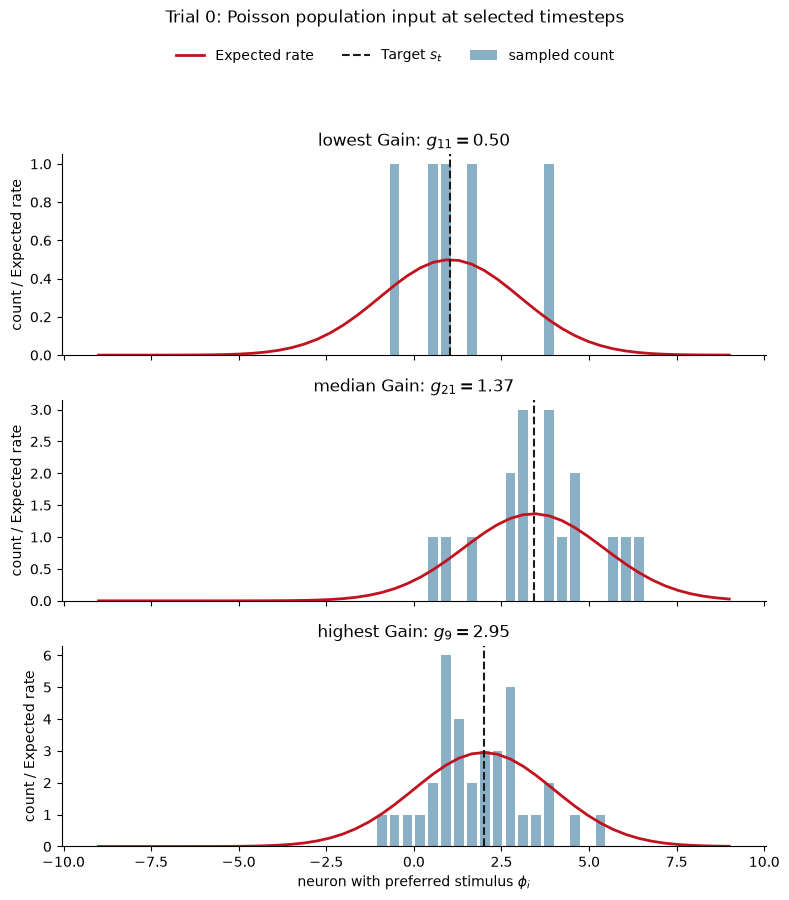

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
for ax, tt, gain_label in zip(axes, selected_times, selected_labels):
    ax.bar(
        phi,
        spikes[tt],
        width=0.28,
        color="#2a6f97",
        alpha=0.55,
        label="sampled count",
    )
    ax.plot(phi, expected_rate[tt], color="#c1121f", lw=2, label="Expected rate")
    ax.axvline(s[tt], color="#1a1a1a", lw=1.5, ls="--", label="Target $s_t$")
    ax.set_title(f"{gain_label} Gain: $g_{{{tt}}}={gain[tt]:.2f}$")
    ax.set_ylabel("count / Expected rate")

axes[-1].set_xlabel("neuron with preferred stimulus $\\phi_i$")
handles, labels = axes[-1].get_legend_handles_labels()
fig.suptitle(
    f"Trial {trial_idx}: Poisson population input at selected timesteps",
    y=0.995,
)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=3,
    frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

### B. Full-Trial population activity

The Expected-rate heatmap shows the hidden generative profile. The spike-count heatmap shows the sampled input that the RNN actually receives.

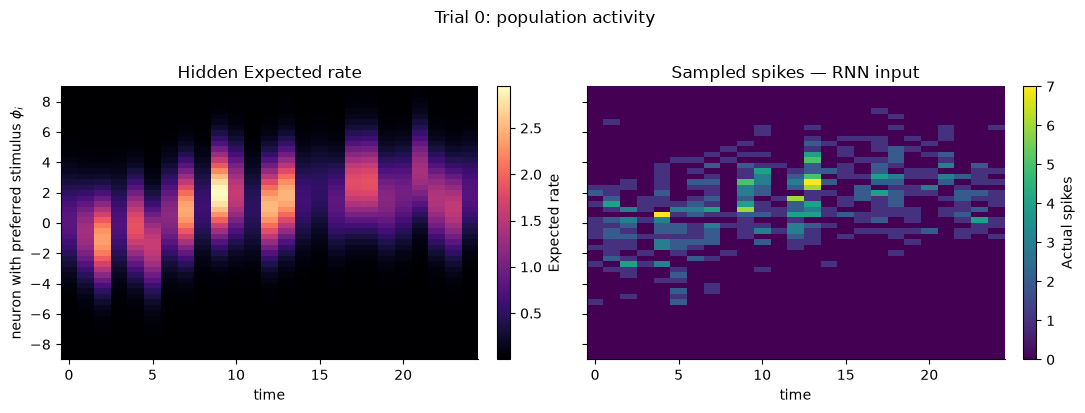

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
extent = (-0.5, len(t) - 0.5, phi[0], phi[-1])

rate_im = axes[0].imshow(
    expected_rate.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="magma",
    extent=extent,
)
spike_im = axes[1].imshow(
    spikes.T,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    cmap="viridis",
    extent=extent,
)

axes[0].set_title("Hidden Expected rate")
axes[1].set_title("Sampled spikes — RNN input")
for ax in axes:
    ax.set_xlabel("time")
axes[0].set_ylabel("neuron with preferred stimulus $\\phi_i$")
fig.colorbar(rate_im, ax=axes[0], fraction=0.046, pad=0.04, label="Expected rate")
fig.colorbar(spike_im, ax=axes[1], fraction=0.046, pad=0.04, label="Actual spikes")
fig.suptitle(f"Trial {trial_idx}: population activity", y=1.02)
fig.tight_layout()
plt.show()

### C. What the RNN can infer from its input

Population count is an observable proxy for the hidden Gain. The Instantaneous population estimate summarizes the stimulus location encoded by the current spikes without using temporal history.

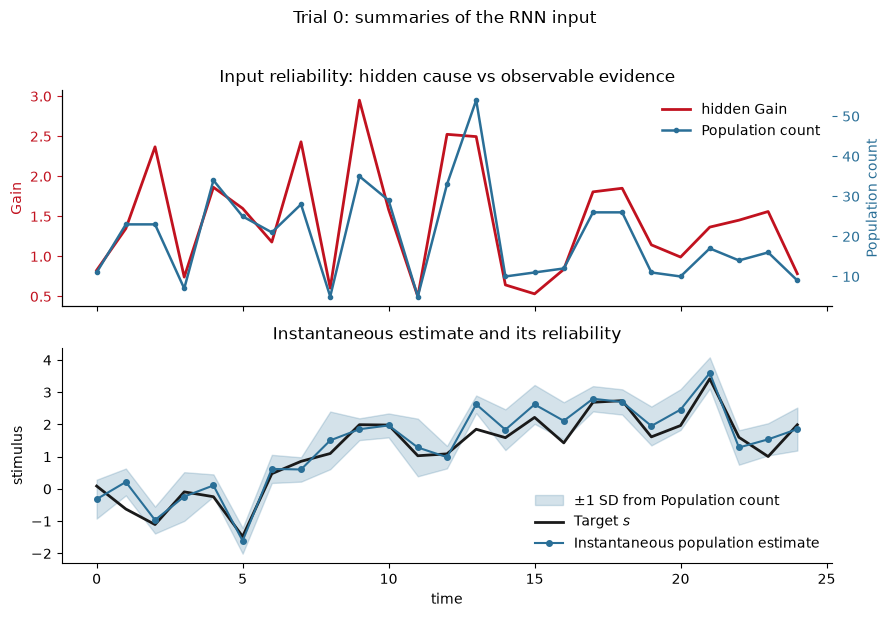

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

count_ax = axes[0].twinx()
gain_line = axes[0].plot(t, gain, color="#c1121f", lw=2, label="hidden Gain")
count_line = count_ax.plot(
    t,
    population_count,
    color="#2a6f97",
    lw=1.8,
    marker="o",
    ms=3,
    label="Population count",
)
axes[0].set_ylabel("Gain", color="#c1121f")
count_ax.set_ylabel("Population count", color="#2a6f97")
axes[0].tick_params(axis="y", colors="#c1121f")
count_ax.tick_params(axis="y", colors="#2a6f97")
axes[0].set_title("Input reliability: hidden cause vs observable evidence")
axes[0].legend(gain_line + count_line, [line.get_label() for line in gain_line + count_line], frameon=False)

axes[1].fill_between(
    t,
    population_estimate - population_sd,
    population_estimate + population_sd,
    color="#2a6f97",
    alpha=0.2,
    label="±1 SD from Population count",
)
axes[1].plot(t, s, color="#1a1a1a", lw=2, label="Target $s$")
axes[1].plot(
    t,
    population_estimate,
    color="#2a6f97",
    lw=1.5,
    marker="o",
    ms=4,
    label="Instantaneous population estimate",
)
axes[1].set_xlabel("time")
axes[1].set_ylabel("stimulus")
axes[1].set_title("Instantaneous estimate and its reliability")
axes[1].legend(frameon=False)

fig.suptitle(f"Trial {trial_idx}: summaries of the RNN input", y=1.02)
fig.tight_layout()
plt.show()

### D. Instantaneous estimate vs optimal estimate

The Instantaneous population estimate uses only the spikes at the current timestep. The Opt mean recursively combines that evidence with prior timesteps. Both are overlaid with the true Target; shaded regions show ±1 standard deviation.

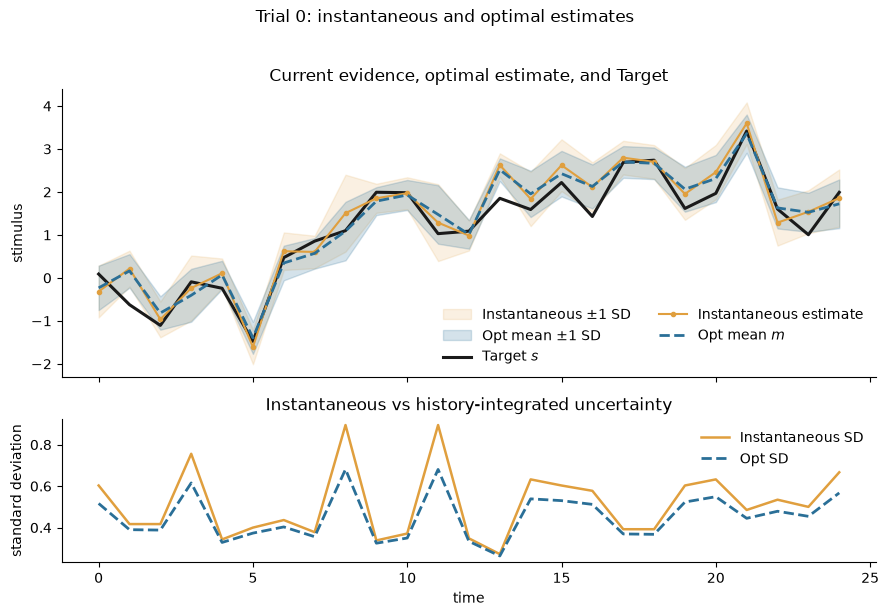

In [30]:
opt_sd = np.sqrt(opt_var)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

axes[0].fill_between(
    t,
    population_estimate - population_sd,
    population_estimate + population_sd,
    color="#e09f3e",
    alpha=0.15,
    label="Instantaneous ±1 SD",
)
axes[0].fill_between(
    t,
    m - opt_sd,
    m + opt_sd,
    color="#2a6f97",
    alpha=0.2,
    label="Opt mean ±1 SD",
)
axes[0].plot(t, s, color="#1a1a1a", lw=2.2, label="Target $s$")
axes[0].plot(
    t,
    population_estimate,
    color="#e09f3e",
    lw=1.5,
    marker="o",
    ms=3,
    label="Instantaneous estimate",
)
axes[0].plot(t, m, color="#2a6f97", lw=2, ls="--", label="Opt mean $m$")
axes[0].set_ylabel("stimulus")
axes[0].set_title("Current evidence, optimal estimate, and Target")
axes[0].legend(frameon=False, ncols=2)

axes[1].plot(t, population_sd, color="#e09f3e", lw=1.8, label="Instantaneous SD")
axes[1].plot(t, opt_sd, color="#2a6f97", lw=2, ls="--", label="Opt SD")
axes[1].set_xlabel("time")
axes[1].set_ylabel("standard deviation")
axes[1].set_title("Instantaneous vs history-integrated uncertainty")
axes[1].legend(frameon=False)

fig.suptitle(f"Trial {trial_idx}: instantaneous and optimal estimates", y=1.02)
fig.tight_layout()
plt.show()

## Train and visualize the network

Adam minimizes **Training loss** (final-timestep MSE vs Target). Logs use **Fractional RMSE** vs Opt mean every `log_every` batches. Run once, then skip this cell and load the checkpoint below.

Defaults match the paper port: 50 001 train batches, batch size 10, lr `2e-4`.

In [31]:
from pathlib import Path
import torch

from paper_pytorch.train import (
    DEFAULT_CHECKPOINT,
    batch_to_tensors,
    load_checkpoint,
    train,
)

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT = REPO_ROOT / DEFAULT_CHECKPOINT
print(f"device={DEVICE}, checkpoint={CHECKPOINT}")
if DEVICE == "cpu":
    print("Note: CUDA unavailable here; full 50k run will be slower on CPU.")

device=cpu, checkpoint=/home/jacob/kalnet/notebooks/kalnet/kalnet/kalman_checkpoints/kf_allgains.pt
Note: CUDA unavailable here; full 50k run will be slower on CPU.


/home/jacob/kalnet/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [32]:
# Skip if CHECKPOINT already exists and you only want to plot.
result = train(
    max_iter=50_001,
    test_iter=2_501,
    batch_size=10,
    log_every=500,
    lr=2e-4,
    tr_cond="all_gains",
    test_cond="all_gains",
    seed=SEED,
    device=DEVICE,
    save_path=CHECKPOINT,
)
print(
    f"test Fractional RMSE={result['frac_rmse_test']:.4f}, "
    f"saved {CHECKPOINT.resolve()}"
)

Batch #0; Frac. RMSE: 5.924677; Opt. RMSE: 0.466650; Net. RMSE: 3.231403
Batch #500; Frac. RMSE: 1.550894; Opt. RMSE: 0.447285; Net. RMSE: 1.140978
Batch #1000; Frac. RMSE: 0.676962; Opt. RMSE: 0.465338; Net. RMSE: 0.780355
Batch #1500; Frac. RMSE: 0.609614; Opt. RMSE: 0.444635; Net. RMSE: 0.715690
Batch #2000; Frac. RMSE: 0.477678; Opt. RMSE: 0.439212; Net. RMSE: 0.649014
Batch #2500; Frac. RMSE: 0.387528; Opt. RMSE: 0.456974; Net. RMSE: 0.634064
Batch #3000; Frac. RMSE: 0.336195; Opt. RMSE: 0.451116; Net. RMSE: 0.602780
Batch #3500; Frac. RMSE: 0.335454; Opt. RMSE: 0.453975; Net. RMSE: 0.606262
Batch #4000; Frac. RMSE: 0.293923; Opt. RMSE: 0.452766; Net. RMSE: 0.585844
Batch #4500; Frac. RMSE: 0.265121; Opt. RMSE: 0.459704; Net. RMSE: 0.581582
Batch #5000; Frac. RMSE: 0.268170; Opt. RMSE: 0.456084; Net. RMSE: 0.578391
Batch #5500; Frac. RMSE: 0.244340; Opt. RMSE: 0.452246; Net. RMSE: 0.562747
Batch #6000; Frac. RMSE: 0.222521; Opt. RMSE: 0.465443; Net. RMSE: 0.569013
Batch #6500; Fra

## Load checkpoint and visualize training

### Fractional RMSE learning curve

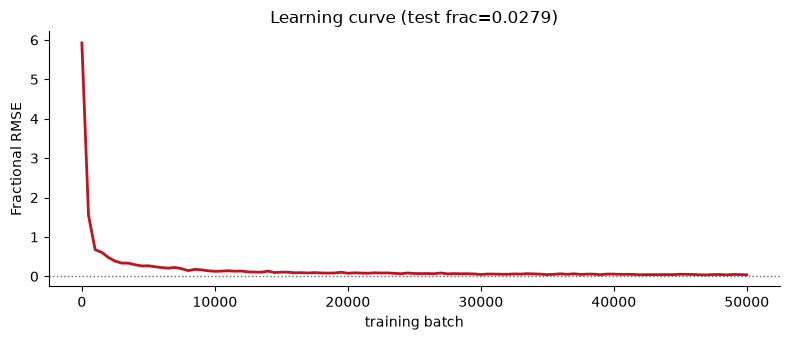

{'n_in': 50,
 'n_hid': 200,
 'stim_dur': 25,
 'batch_size': 10,
 'lr': 0.0002,
 'tr_cond': 'all_gains',
 'test_cond': 'all_gains',
 'seed': 0,
 'log_every': 500,
 'max_iter': 50001}

In [33]:
loaded = load_checkpoint(CHECKPOINT, device=DEVICE)
model = loaded["model"]
cfg = loaded["config"]
frac = loaded["frac_rmse_vec"]
log_every = cfg.get("log_every", 500)
batches = np.arange(len(frac)) * log_every

fig, ax = plt.subplots()
ax.plot(batches, frac, color="#c1121f", lw=2)
ax.axhline(0.0, color="#666666", lw=1, ls=":")
ax.set_xlabel("training batch")
ax.set_ylabel("Fractional RMSE")
ax.set_title(
    f"Learning curve (test frac={loaded['frac_rmse_test']:.4f})"
)
fig.tight_layout()
plt.show()
cfg

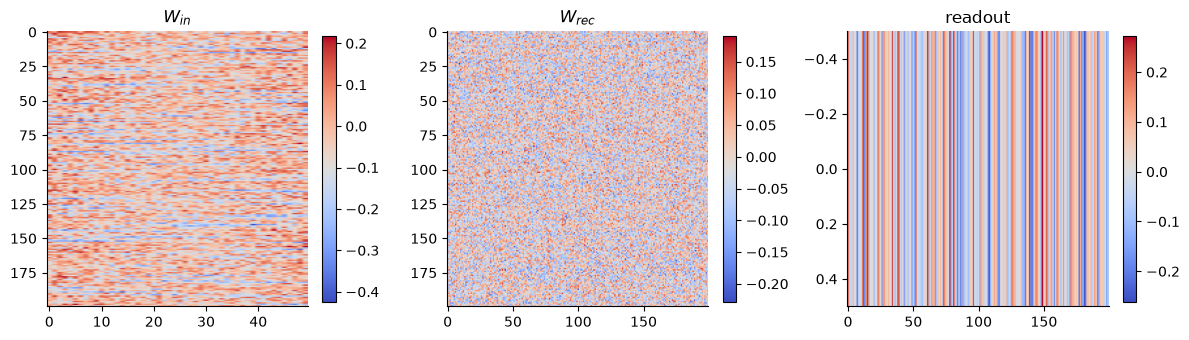

In [38]:
W_in = model.W_in.weight.detach().cpu().numpy()      # (n_hid, n_in)
W_rec = model.W_rec.weight.detach().cpu().numpy()    # (n_hid, n_hid)
w_out = model.readout.weight.detach().cpu().numpy()  # (1, n_hid)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, mat, title in zip(
    axes,
    [W_in, W_rec, w_out],
    ["$W_{in}$", "$W_{rec}$", "readout"],
):
    im = ax.imshow(mat, aspect="auto", cmap="coolwarm")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()